## 1.Introduction

This tutorial will demonstrate entropy and open circuit voltage (OCV) estimation process from charge/discharge data in step by step manner. After this tutorial you will be able to estimate open circuit voltage and entropy from your own experimental charge/discharge data.

The tutorial is provided as a jupyter notebook in form of multiple script cells, that can be modified and adjusted to your needs. Some basic understading in Python coding is assumed.

List of tutorials steps:
1.Introduction (you are here)
2.Experiment data
3.Experiment data conversion
4.Entropy and OCV estimation
5.Entropy and OCP estimation

### Brief introduction to Jupyter notebook and Python 

In case you are new to Jupyter and Python, here is a brief introduction:

Jupyter notebook (just like this one) allows you to combine the python code cells and enrich it with explanaition text. Jupyter notebook is made up of code and text cells that can be executed step wise one by one (just like this one) or code cell bellow.

In [1]:
Hours_in_a_year = 24 * 365
print (Hours_in_a_year)

8760


To execute the code cell above you can hover over the cell and "Execute cell" button will apear, click it to execute code cell. Clicking the cell and pressing "Ctrl + Enter" will also execute the cell. "print" function displays variable value that is inside the brackets upon execution

In [2]:
Minutes_in_a_day = 60 * 24

Code cell above defines a variable in the script denying the variable print. Variables defined in the code cells can be used in later code cells through out the notebook file. This briefely covers the Jupyter notebook and python introduction.

## 2.Experiment Data

In this section we will breif you on what are the experiment data requirements how should the experiment data excel file be formated, what it should contain and how it should be named to be processed.

#### Data requirements

-  Charge/Discharge at 25°C (required)
-  Charge/discharge at other than 25°C (at least 1 dataset is required for entropy estimation)

#### Data file name designation

The process utlizes a speciffic experiment data file naming scheme to call the experiment datasets for the estimation process. Experiment data files names have:

-   Cell code name "CellID" (Example: "TestCell")
-   Temperature in Celsius the experiment was performed at noted with "P" for positive and "N" for negative (sub zero) temperatures
-   Experiment protocol if cell was discharged or charged noted with "S1" and "S3" respectively

Example of a name of a dataset that contains discharge data at  25°C: "TestCell_OCV_P25_S1".
Datasets with the same cell code name must be in the folder having the cell code name. Example folder: "TestCell_OCV"

#### What should dataset contain

-   The charge/discharge experiments can have many different data types, here we are going to show the essential data that is required for the estimation porcess excecution:
-   Voltage (V)
-   Current step index 
-   Charge capacity (Ah)
-   Discharge capacity (Ah)

Above are the esential data columns in the experiment dataset for the estimation process to complete. Additionally, the dataset should have at least 1 data recording before applying current and after applying current. Below is a simple example of how the dataset should look like and what it should contain:

In [3]:
import pandas as pd
import numpy as np

Example_dataset = pd.read_excel(r"TestCell_OCV\TestCell_OCV_P25_S1.xlsx")

print(Example_dataset)

   Voltage(V)  Current(A)  Step_Index  Test_Time(s)  Discharge_Capacity(Ah)  \
0         3.5           0           1             0                       0   
1         3.0         -50           2           600                      30   
2         2.5           0           3          3600                     100   

   Charge_Capacity(Ah)  
0                    0  
1                    0  
2                    0  


Now that we know how the experiment data file should look like and what are the requirements, the experiment data files can be formated accordingly. 

## 3.Experiment data conversion

With experiment data format in place we can convert the experiment data from excel to python dataframe format.
We begin by calling the cell code name and temperatures at which the experiments were performed.

In [4]:
cellIDs = ["MCell"]      # Identifiers for each cell
order = [45, 25, 10, 0]  # Temperatures for each (°C)

Then we inform python from which columns the data should be converted to python dataframe format via column headers (Note!: they must be identical to what is in the excel files to be read). Then define the data column headers in python as follows:

In [5]:
headers = [
    "Step_Index",
    "Voltage(V)",
    "Charge_Capacity(Ah)",
    "Discharge_Capacity(Ah)"
]

# Corresponding field names to use internally
fields = ["step", "voltage", "chgAh", "disAh"]
column_map = dict(zip(headers, fields))

# Field names for the four different testing scripts
stepFields = ["script1", "script2", "script3", "script4"]

Now we can loop through the data with defined indentity information and convert the desired datasets from excel to Python dataframe as following.

In [6]:
from pathlib import Path

for cellID in cellIDs:

    dirname = cellID.split("_")[0]  # remove "_" and everything after

    for temp in order:

        # Build file prefix
        if temp < 0:
            prefix = f"{dirname}_OCV/{cellID}_OCV_N{abs(temp):02d}"
        else:
            prefix = f"{dirname}_OCV/{cellID}_OCV_P{temp:02d}"

        data = {}

        # MATLAB used [1,3]
        for script in [1, 3]:

            file_path = Path(f"{prefix}_S{script}.xlsx")

            if not file_path.exists():
                print(f"File not found: {file_path}")
                continue

            print(f"Reading {file_path}")

            xls = pd.ExcelFile(file_path)
            OCVData = []

            for sheet in xls.sheet_names:
                if sheet == "Info":
                    continue

                print(f"Processing sheet {sheet}")
                df = pd.read_excel(file_path, sheet_name=sheet)

                df_filtered = df[headers].rename(columns=column_map)
                OCVData.append(df_filtered)

            if OCVData:
                combined_df = pd.concat(OCVData, ignore_index=True)

                # 🔹 Save directly next to original Excel file
                out_file = file_path.with_suffix(".pkl")
                combined_df.to_pickle(out_file)

                print(f"Saved {out_file}")

Reading MCell_OCV\MCell_OCV_P45_S1.xlsx
Processing sheet MCell_OCV_P45_S1
Saved MCell_OCV\MCell_OCV_P45_S1.pkl
Reading MCell_OCV\MCell_OCV_P45_S3.xlsx
Processing sheet MCell_OCV_P45_S3
Saved MCell_OCV\MCell_OCV_P45_S3.pkl
Reading MCell_OCV\MCell_OCV_P25_S1.xlsx
Processing sheet MCell_OCV_P25_S1
Saved MCell_OCV\MCell_OCV_P25_S1.pkl
Reading MCell_OCV\MCell_OCV_P25_S3.xlsx
Processing sheet MCell_OCV_P25_S3
Saved MCell_OCV\MCell_OCV_P25_S3.pkl
Reading MCell_OCV\MCell_OCV_P10_S1.xlsx
Processing sheet MCell_OCV_P10_S1
Saved MCell_OCV\MCell_OCV_P10_S1.pkl
Reading MCell_OCV\MCell_OCV_P10_S3.xlsx
Processing sheet MCell_OCV_P10_S3
Saved MCell_OCV\MCell_OCV_P10_S3.pkl
Reading MCell_OCV\MCell_OCV_P00_S1.xlsx
Processing sheet MCell_OCV_P0_S1
Saved MCell_OCV\MCell_OCV_P00_S1.pkl
Reading MCell_OCV\MCell_OCV_P00_S3.xlsx
Processing sheet MCell_OCV_P0_S3
Saved MCell_OCV\MCell_OCV_P00_S3.pkl


### 4.Entropy and OCV estimation
With experiment data in python dataframe format, we can use it to estimate entropy coefficient and OCV. We begin by calling the cell code name and temperature, additionally we also define maximum and minimum voltages for plotting purposes as follows:

Reseting workspace environment

In [7]:
%reset -f

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

Defining cell data identification and voltage plot limits 

In [8]:
# Identifiers for each cell
cellIDs = ["MCell"]

# Available temperatures for each cell
temps = [[45, 25, 10, 0]]

# Voltage limits for plotting
minV = [2.5]
maxV = [3.65]

Now we can call the estimation algorithm to estimate the entropy coefficient and OCV from desired datasets as follows:

Processed model saved to MCell_model_ocv.pkl


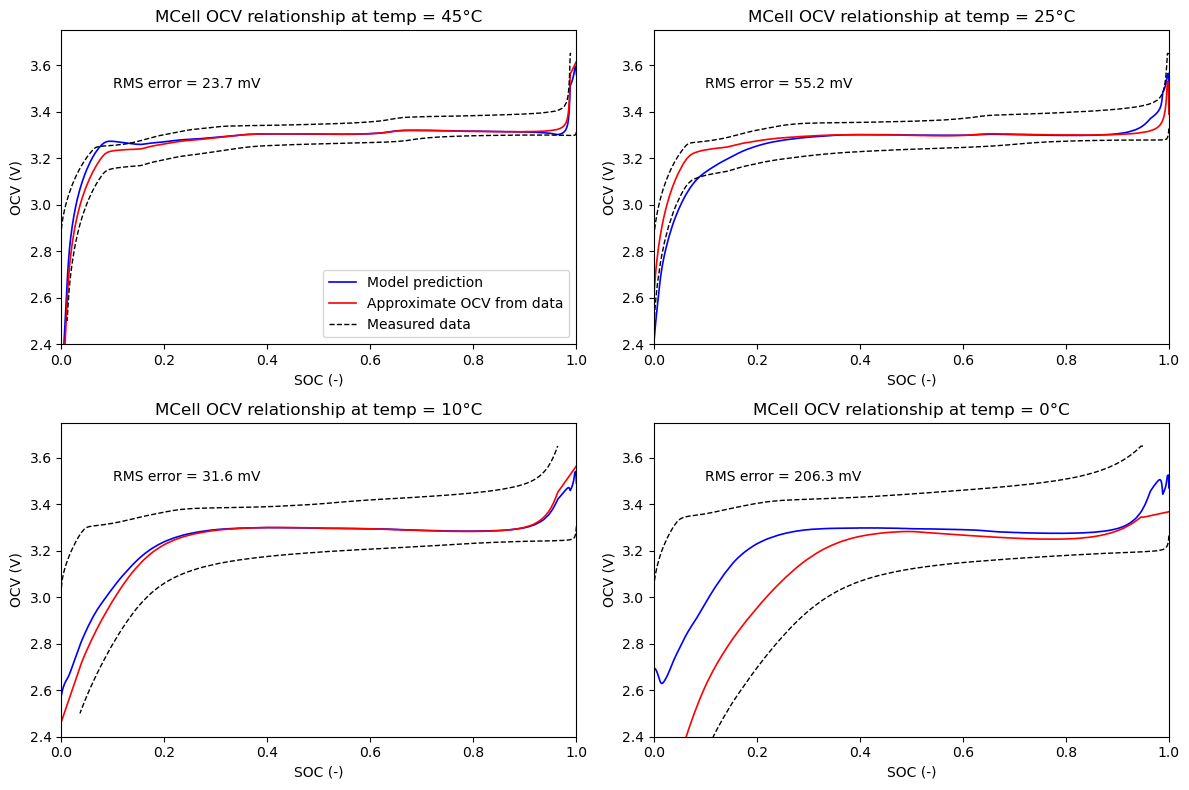

In [9]:
import os
import pickle
from process_function_OCV import processOCV  # previously converted function

# Example variables (should come from your notebook or previous code)
# cellIDs = ['MCell']
# temps = [[45, 25, 10, 0]]
# minV = [2.5]
# maxV = [3.65]

for theID, dirname in enumerate(cellIDs):
    cellID = dirname
    # Remove trailing underscore if present
    if '_' in dirname:
        dirname = dirname.split('_')[0]

    OCVDir = f"{dirname}_OCV"
    if not os.path.isdir(OCVDir):
        raise FileNotFoundError(
            f'Folder "{OCVDir}" not found in current folder.\n'
            f'Please change folders so that "{OCVDir}" is in the current folder and re-run.'
        )

    filetemps = np.array(temps[theID])
    numtemps = len(filetemps)
    data = [{} for _ in range(numtemps)]  # initialize data list

    # Load the OCV files
    for k, temp in enumerate(filetemps):

        if temp < 0:
            base = f"{cellID}_OCV_N{abs(temp):02d}"
        else:
            base = f"{cellID}_OCV_P{temp:02d}"

        file_s1 = os.path.join(OCVDir, f"{base}_S1.pkl")
        file_s3 = os.path.join(OCVDir, f"{base}_S3.pkl")

        if not os.path.isfile(file_s1):
            raise FileNotFoundError(f"Data file {file_s1} not found.")

        if not os.path.isfile(file_s3):
            raise FileNotFoundError(f"Data file {file_s3} not found.")

        with open(file_s1, 'rb') as f:
            script1_data = pickle.load(f)

        with open(file_s3, 'rb') as f:
            script3_data = pickle.load(f)

        data[k]['temp'] = temp
        data[k]['script1'] = script1_data
        data[k]['script3'] = script3_data

    # Call the processing function to generate OCV model
    model = processOCV(data, cellID, minV[theID], maxV[theID], savePlots=True)

    # Save model as a .pkl file
    model_filename = f"{cellID}_model_ocv.pkl"
    with open(model_filename, 'wb') as f:
        pickle.dump(model, f)

    print(f"Processed model saved to {model_filename}")

Data is now procced and estimated entropy and OCV profiles can be compiled into tables and figures. This is done in the code cell bellow:

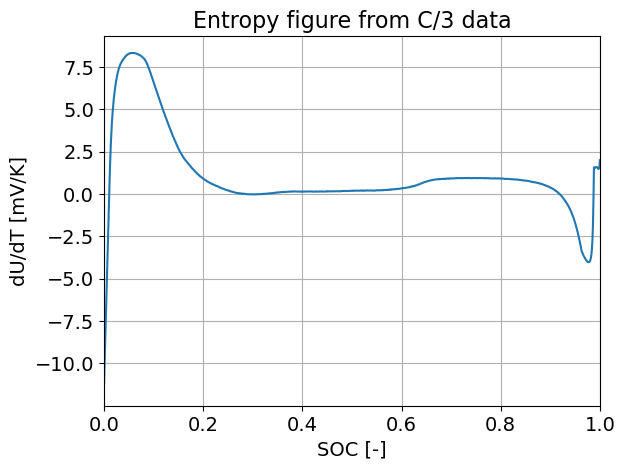

In [10]:
# Create OCV table
OCVTable = pd.DataFrame({
    "SOC": model["SOCaprox"],
    "OCV": model["OCVaprox"]
})

# Create entropy (dU/dT) table
dUdT_Table = pd.DataFrame({
    "SOC": model["SOC"],
    "dUdT": model["OCVrel"]
})

#Export tables as .CSV files
#OCVTable.to_csv("MCell_OCV/MCell_OCV.csv", index=False)   # Uncomment line to save OCV table
#dUdT_Table.to_csv("MCell_OCV/MCell_dUdT.csv", index=False) # Uncomment line to save Entropy profile table

#Ploting the entropy profile C/3

plt.figure()
plt.plot(model["SOC"], 1000 * model["OCVrel"])
plt.grid(True)

plt.title("Entropy figure from C/3 data", fontsize=16)
plt.xlabel("SOC [-]", fontsize=14)
plt.ylabel("dU/dT [mV/K]", fontsize=14)

plt.xlim([0, 1])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

## 5.Entropy and OCP estimation

In this section we adapt the OCV estimation code to estimate open circuit potential (OCP) from half-cell charge/discharge, the process is esentially the same with minor changes, data conversion and estimation process can be found bellow.

### Half-cells experiment data conversion

Input the half-cell code name "ID" and temperatures charge/discharge experiments were performed on half-cells

In [11]:
%reset -f
import pandas as pd
import numpy as np

cellIDs = ["LFPhc"]      # Identifiers for each cell
order = [25]  # Temperatures for each (°C)

headers = [
    "Step_Index",
    "Voltage(V)",
    "Charge_Capacity(mAh)",
    "Discharge_Capacity(mAh)"
]

# Corresponding field names to use internally
fields = ["step", "voltage", "chgmAh", "dismAh"]
column_map = dict(zip(headers, fields))

# Field names for the four different testing scripts
stepFields = ["script1", "script2", "script3", "script4"]

Bellow is the code to convert half-cell charge/discharge experiment:

In [12]:
from pathlib import Path

for cellID in cellIDs:

    dirname = cellID.split("_")[0]  # remove "_" and everything after

    for temp in order:

        # Build file prefix
        if temp < 0:
            prefix = f"{dirname}_OCP/{cellID}_OCP_N{abs(temp):02d}"
        else:
            prefix = f"{dirname}_OCP/{cellID}_OCP_P{temp:02d}"

        data = {}

        # MATLAB used [1,3]
        for script in [1, 3]:

            file_path = Path(f"{prefix}_S{script}.xlsx")

            if not file_path.exists():
                print(f"File not found: {file_path}")
                continue

            print(f"Reading {file_path}")

            xls = pd.ExcelFile(file_path)
            OCVData = []

            for sheet in xls.sheet_names:
                if sheet == "Info":
                    continue

                print(f"Processing sheet {sheet}")
                df = pd.read_excel(file_path, sheet_name=sheet)

                df_filtered = df[headers].rename(columns=column_map)
                OCVData.append(df_filtered)

            if OCVData:
                combined_df = pd.concat(OCVData, ignore_index=True)

                # 🔹 Save directly next to original Excel file
                out_file = file_path.with_suffix(".pkl")
                combined_df.to_pickle(out_file)

                print(f"Saved {out_file}")

Reading LFPhc_OCP\LFPhc_OCP_P25_S1.xlsx
Processing sheet Sheet1
Saved LFPhc_OCP\LFPhc_OCP_P25_S1.pkl
Reading LFPhc_OCP\LFPhc_OCP_P25_S3.xlsx
Processing sheet Sheet1
Saved LFPhc_OCP\LFPhc_OCP_P25_S3.pkl


### Entropy and OCP estimation 

Similarly as to OCV estimation here we define the half-cell code name "ID", operating temepratures and operating voltage limits for ploting purposes. The code is in cell bellow:

In [13]:
%reset -f

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Identifiers for each cell
cellIDs = ["LFPhc"]

# Available temperatures for each cell
temps = [[25]]

# Voltage limits for plotting
minV = [2.5]
maxV = [3.65]

Then we can run the OCP and entropy estimation algorithm to estimate OCP and entropy from half-cell charge/discharge datasets.

Processed model saved to LFPhc_model_ocp.pkl


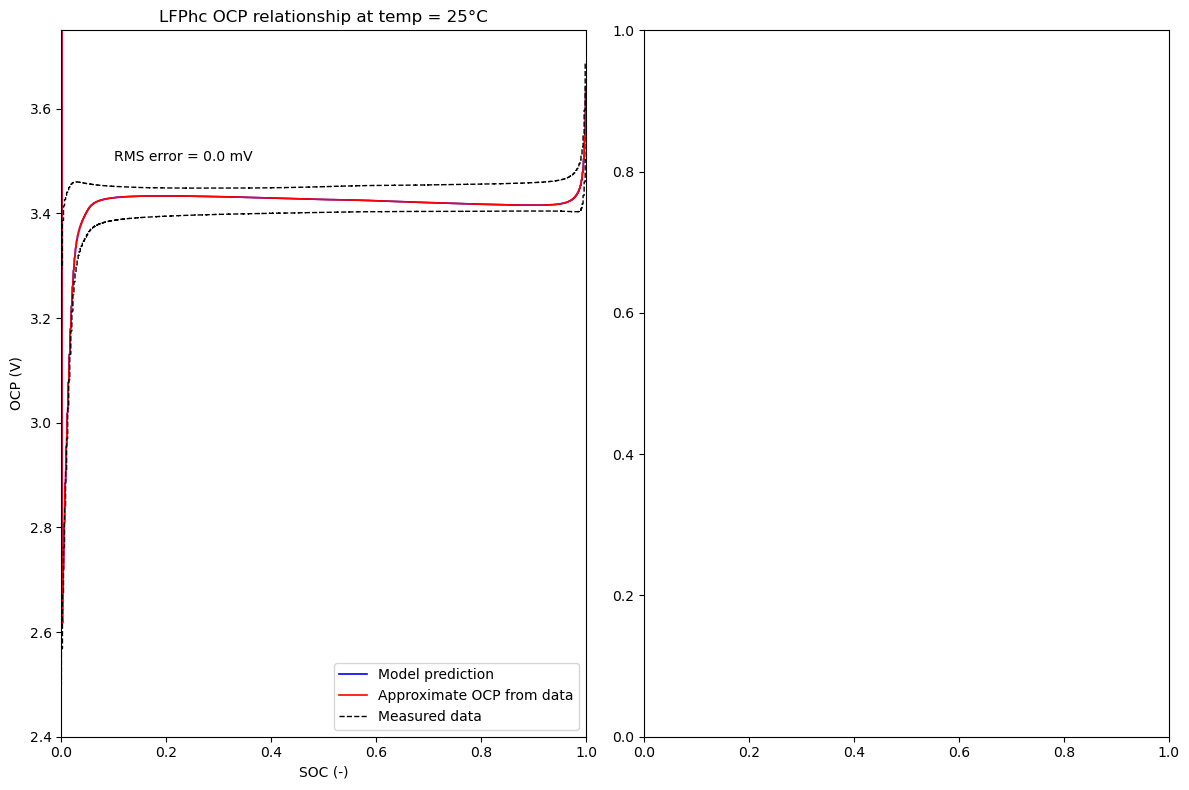

In [14]:
import os
import pickle
from process_function_OCP import processOCP  # previously converted function


for theID, dirname in enumerate(cellIDs):
    cellID = dirname
    # Remove trailing underscore if present
    if '_' in dirname:
        dirname = dirname.split('_')[0]

    OCPDir = f"{dirname}_OCP"
    if not os.path.isdir(OCPDir):
        raise FileNotFoundError(
            f'Folder "{OCPDir}" not found in current folder.\n'
            f'Please change folders so that "{OCPDir}" is in the current folder and re-run.'
        )

    filetemps = np.array(temps[theID])
    numtemps = len(filetemps)
    data = [{} for _ in range(numtemps)]  # initialize data list

    # Load the OCP files
    for k, temp in enumerate(filetemps):

        if temp < 0:
            base = f"{cellID}_OCP_N{abs(temp):02d}"
        else:
            base = f"{cellID}_OCP_P{temp:02d}"

        file_s1 = os.path.join(OCPDir, f"{base}_S1.pkl")
        file_s3 = os.path.join(OCPDir, f"{base}_S3.pkl")

        if not os.path.isfile(file_s1):
            raise FileNotFoundError(f"Data file {file_s1} not found.")

        if not os.path.isfile(file_s3):
            raise FileNotFoundError(f"Data file {file_s3} not found.")

        with open(file_s1, 'rb') as f:
            script1_data = pickle.load(f)

        with open(file_s3, 'rb') as f:
            script3_data = pickle.load(f)

        data[k]['temp'] = temp
        data[k]['script1'] = script1_data
        data[k]['script3'] = script3_data

    # Call the processing function to generate OCP model
    model = processOCP(data, cellID, minV[theID], maxV[theID], savePlots=True)

    # Save model as a .pkl file
    model_filename = f"{cellID}_model_ocp.pkl"
    with open(model_filename, 'wb') as f:
        pickle.dump(model, f)

    print(f"Processed model saved to {model_filename}")

Compilng the OCP and entropy estimation results into tables, and plot entropy profile.

In [15]:
# Create OCP table
OCPTable = pd.DataFrame({
    "SOC": model["SOCaprox"],
    "OCP": model["OCVaprox"]
})

# Create entropy (dU/dT) table
dUdT_Table = pd.DataFrame({
    "SOC": model["SOC"],
    "dUdT": model["OCVrel"]
})

#Export tables as .CSV files
#OCVTable.to_csv("MCell_OCV/MCell_OCV.csv", index=False)   # Uncomment line to save OCV table
#dUdT_Table.to_csv("MCell_OCV/MCell_dUdT.csv", index=False) # Uncomment line to save Entropy profile table

## 6.Discussion

This toolbox provides scripts to estimate OCV, OCP and thier respective entropy profiles. It allows you to save them in your desired format, may it be cvs, excel or other typical table formats. The exported estimates then can be used as input in a moddeling and simulation software to create your own OCV, OCP and introduce entropy profiles for them. Feel free to use this toolbox with your own data to get your own open circuit voltage estimations 
